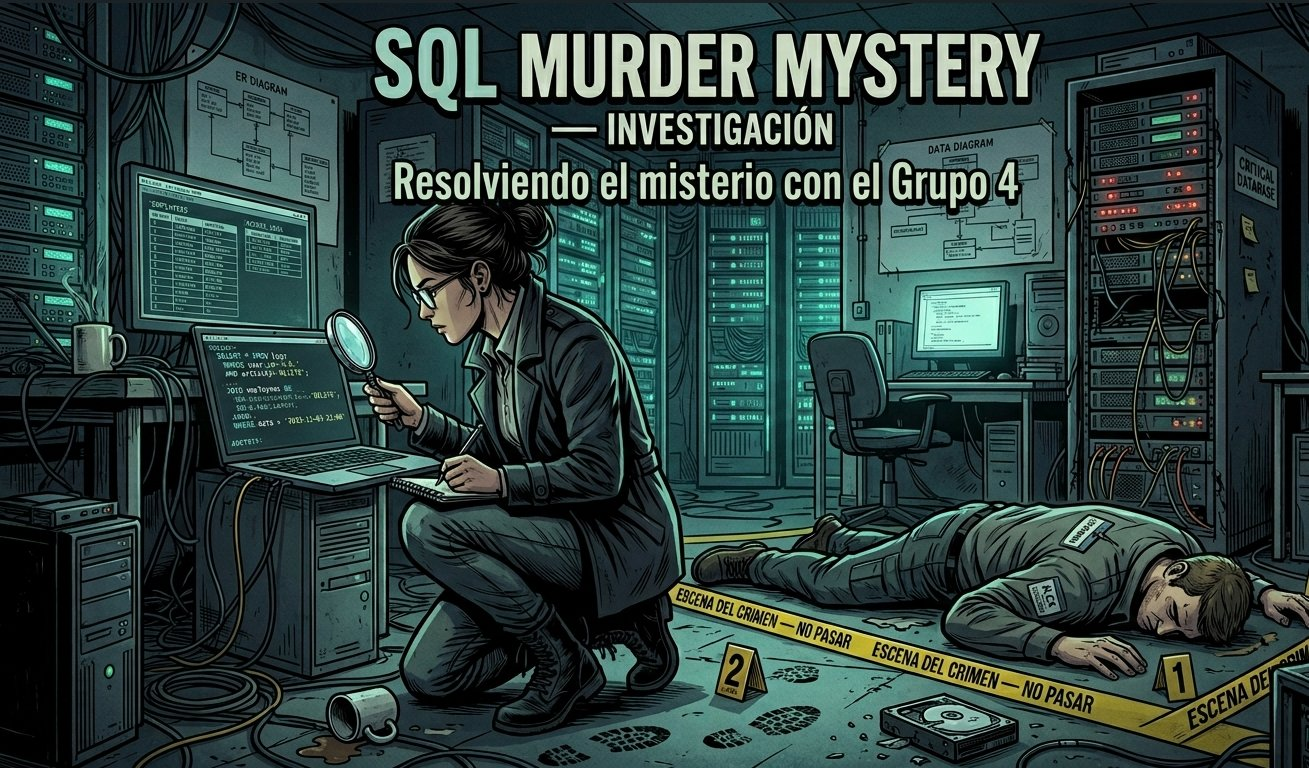

# 🔍 SQL Murder Mystery — Investigación

**Equipo:** Grupo 4  
**Fecha del crimen:** 15 de enero de 2018  
**Ciudad:** SQL City  
**Tipo de crimen:** Murder  

---
## ⚙️ Setup — Conexión a la base de datos

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('data/sql-murder-mystery.db')
print('Conexión establecida ✅')

---
## Paso 1 — Recuperar el informe del crimen

Buscamos en `crime_scene_report` el asesinato del 15 de enero de 2018 en SQL City.

In [ ]:
query = """
SELECT *
FROM   crime_scene_report
WHERE  type = 'murder'
  AND  date = 20180115
  AND  city = 'SQL City'
"""
pd.read_sql_query(query, conn)

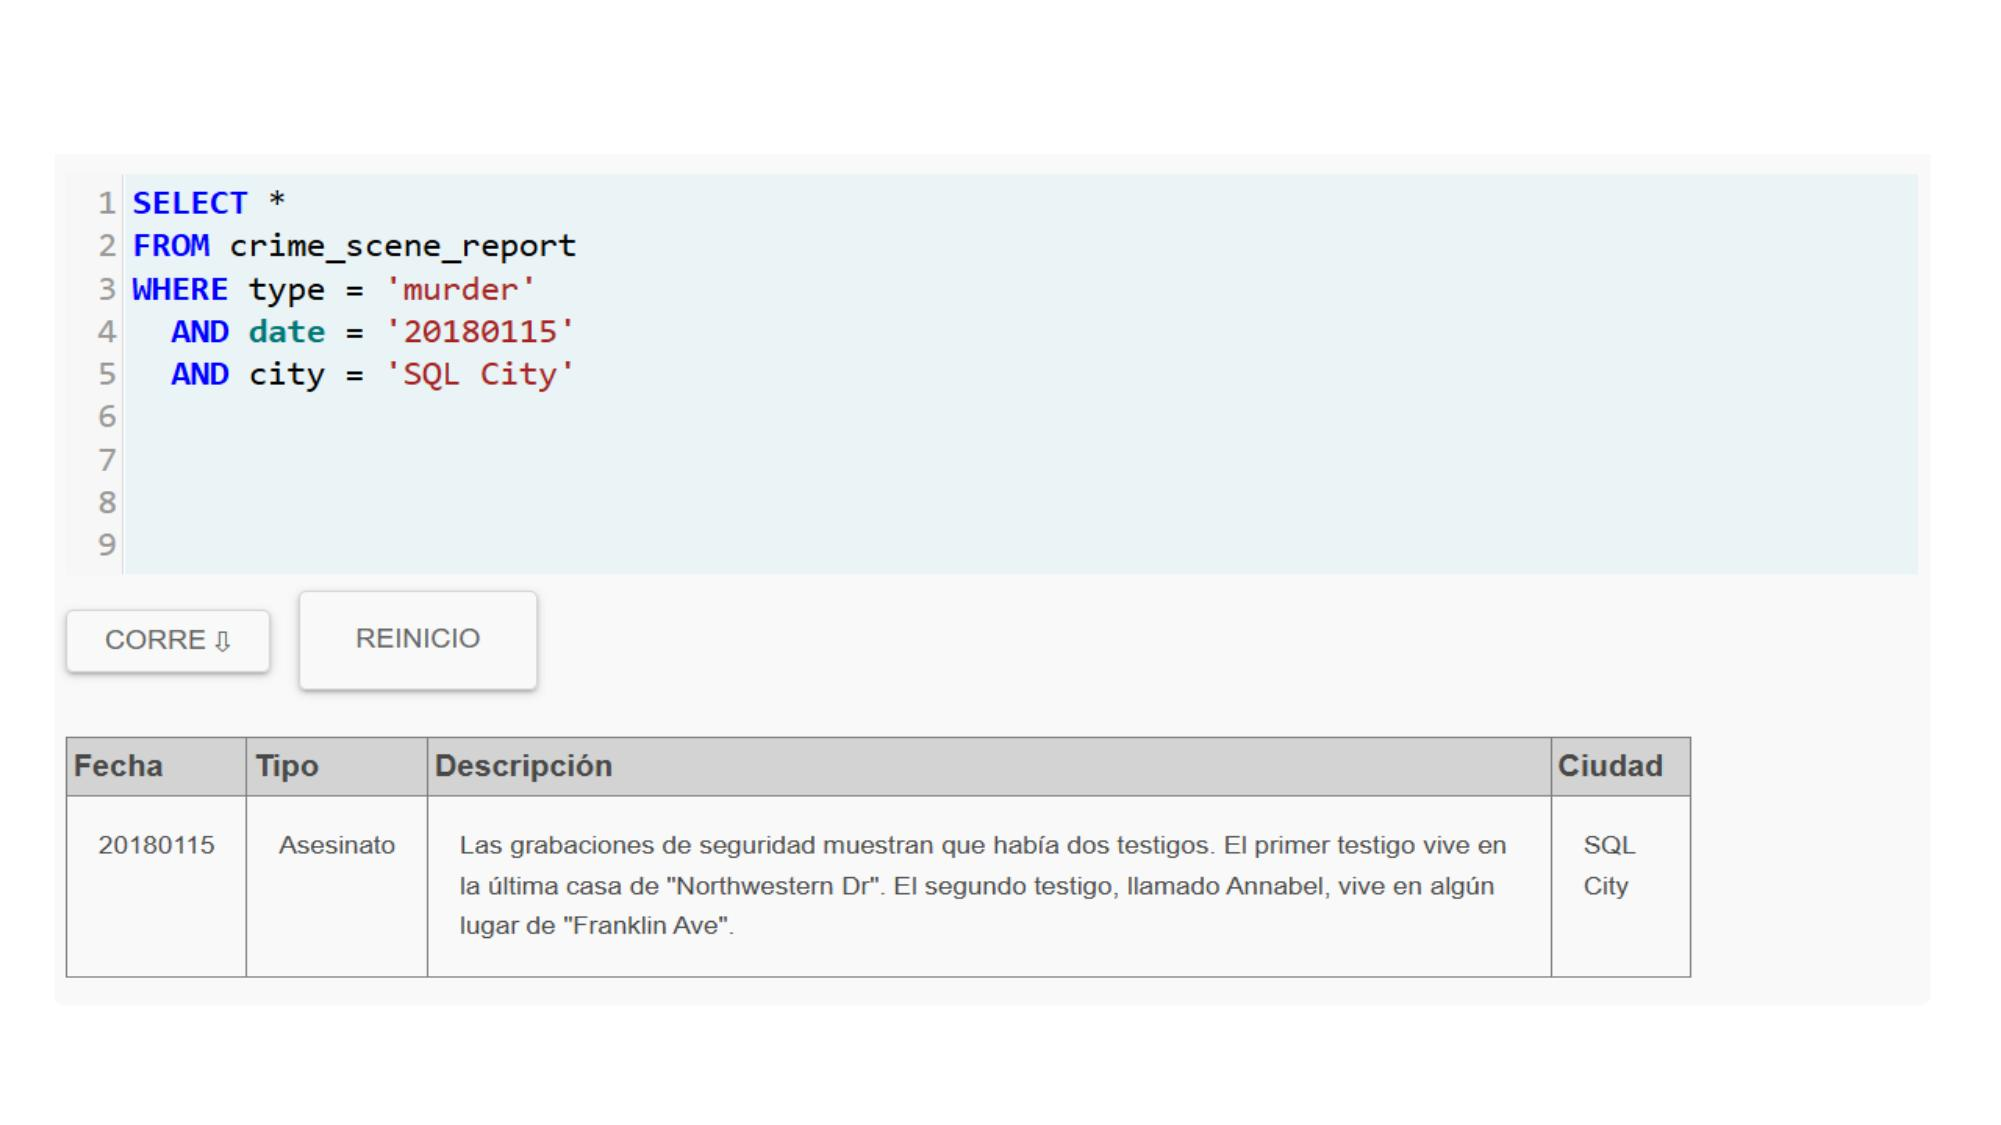

**Pistas obtenidas:**
- Testigo 1: vive en la **última casa** de Northwestern Dr
- Testigo 2: se llama **Annabel** y vive en Franklin Ave

---
## Paso 2 — Localizar a los testigos

### Testigo 1 — última casa de Northwestern Dr

Ordenamos por `address_number` de forma descendente y limitamos a 1 resultado.

In [ ]:
query = """
SELECT *
FROM   person
WHERE  address_street_name = 'Northwestern Dr'
ORDER BY address_number DESC
LIMIT 1
"""
pd.read_sql_query(query, conn)

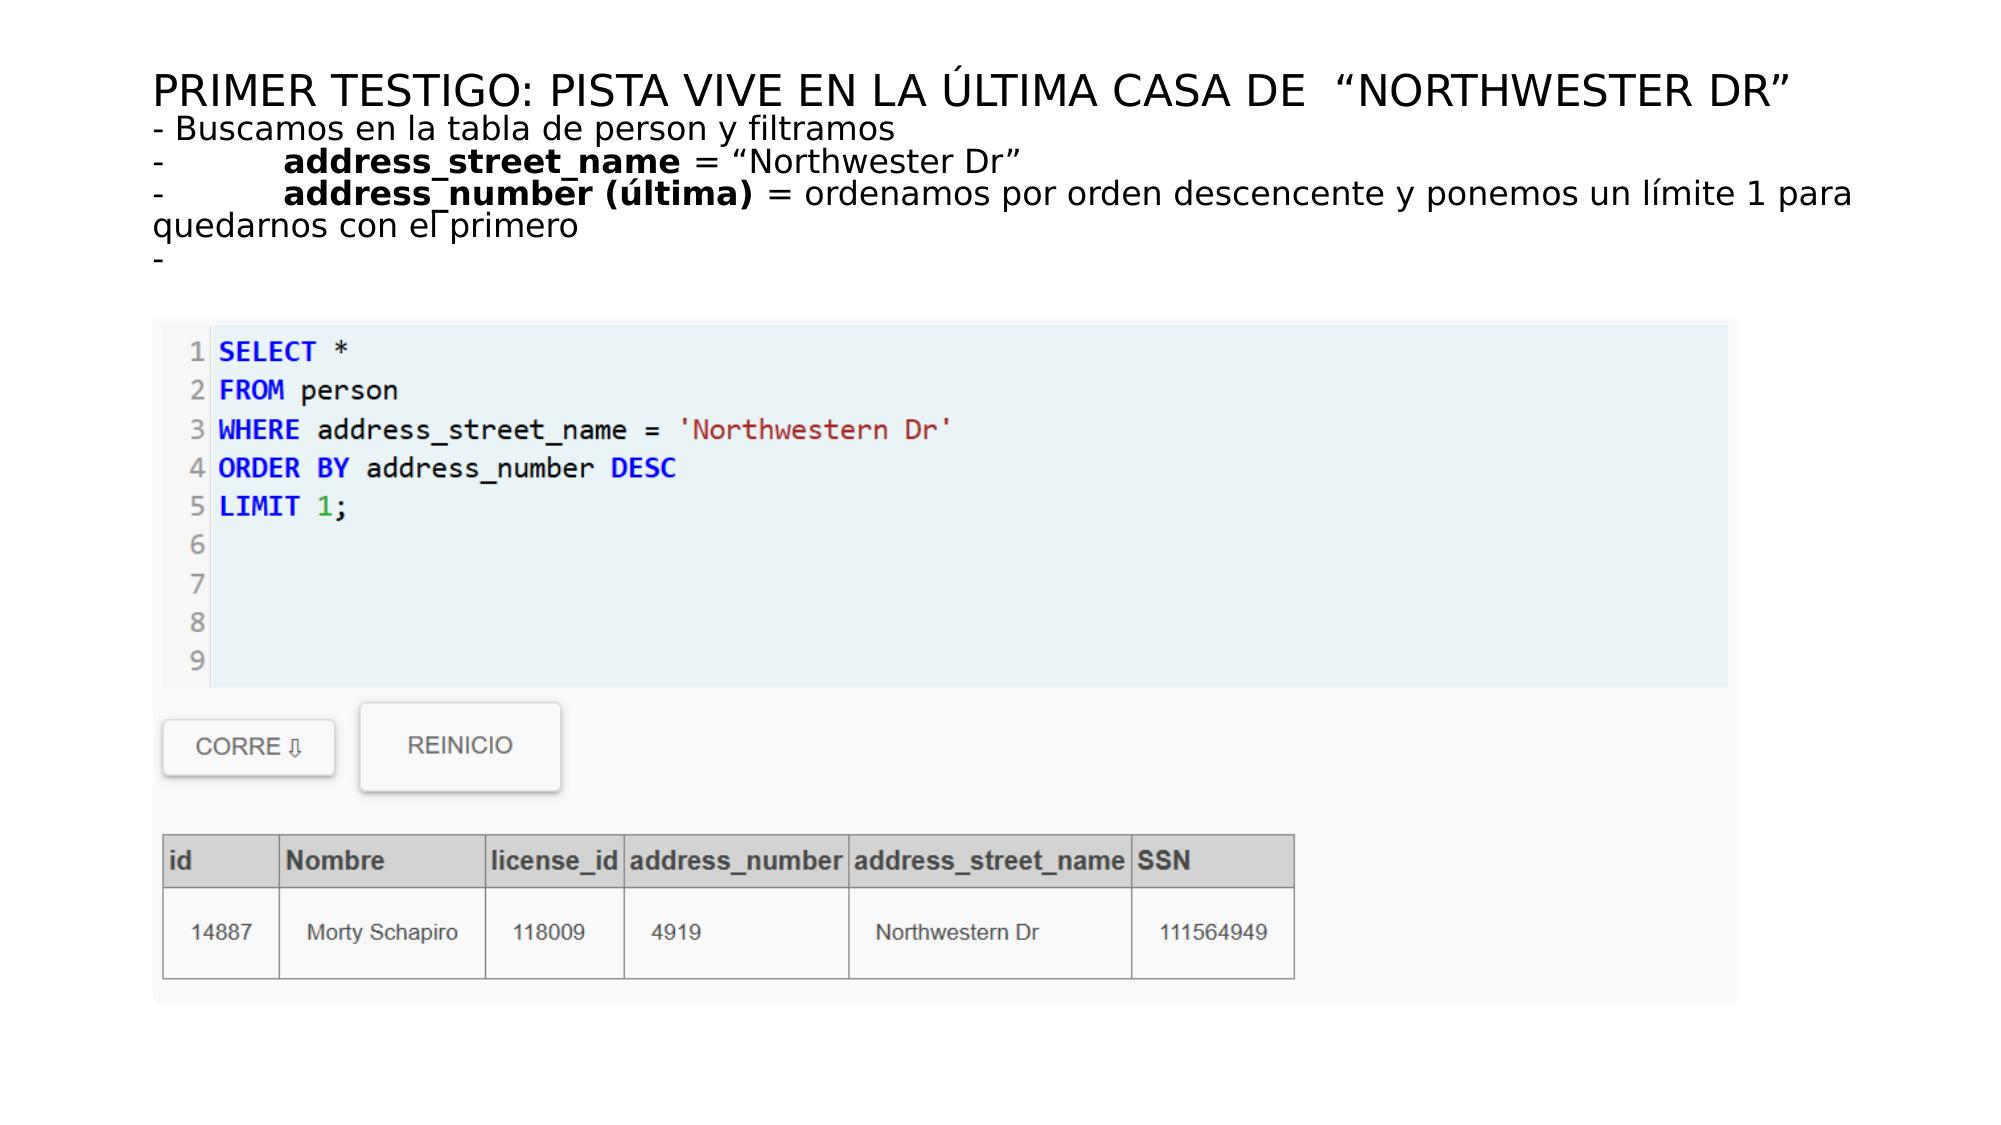

**Resultado:** Testigo 1 → **Morty Schapiro** (id: 14887)

### Testigo 2 — Annabel en Franklin Ave

In [ ]:
query = """
SELECT *
FROM   person
WHERE  name LIKE '%Annabel%'
  AND  address_street_name = 'Franklin Ave'
"""
pd.read_sql_query(query, conn)

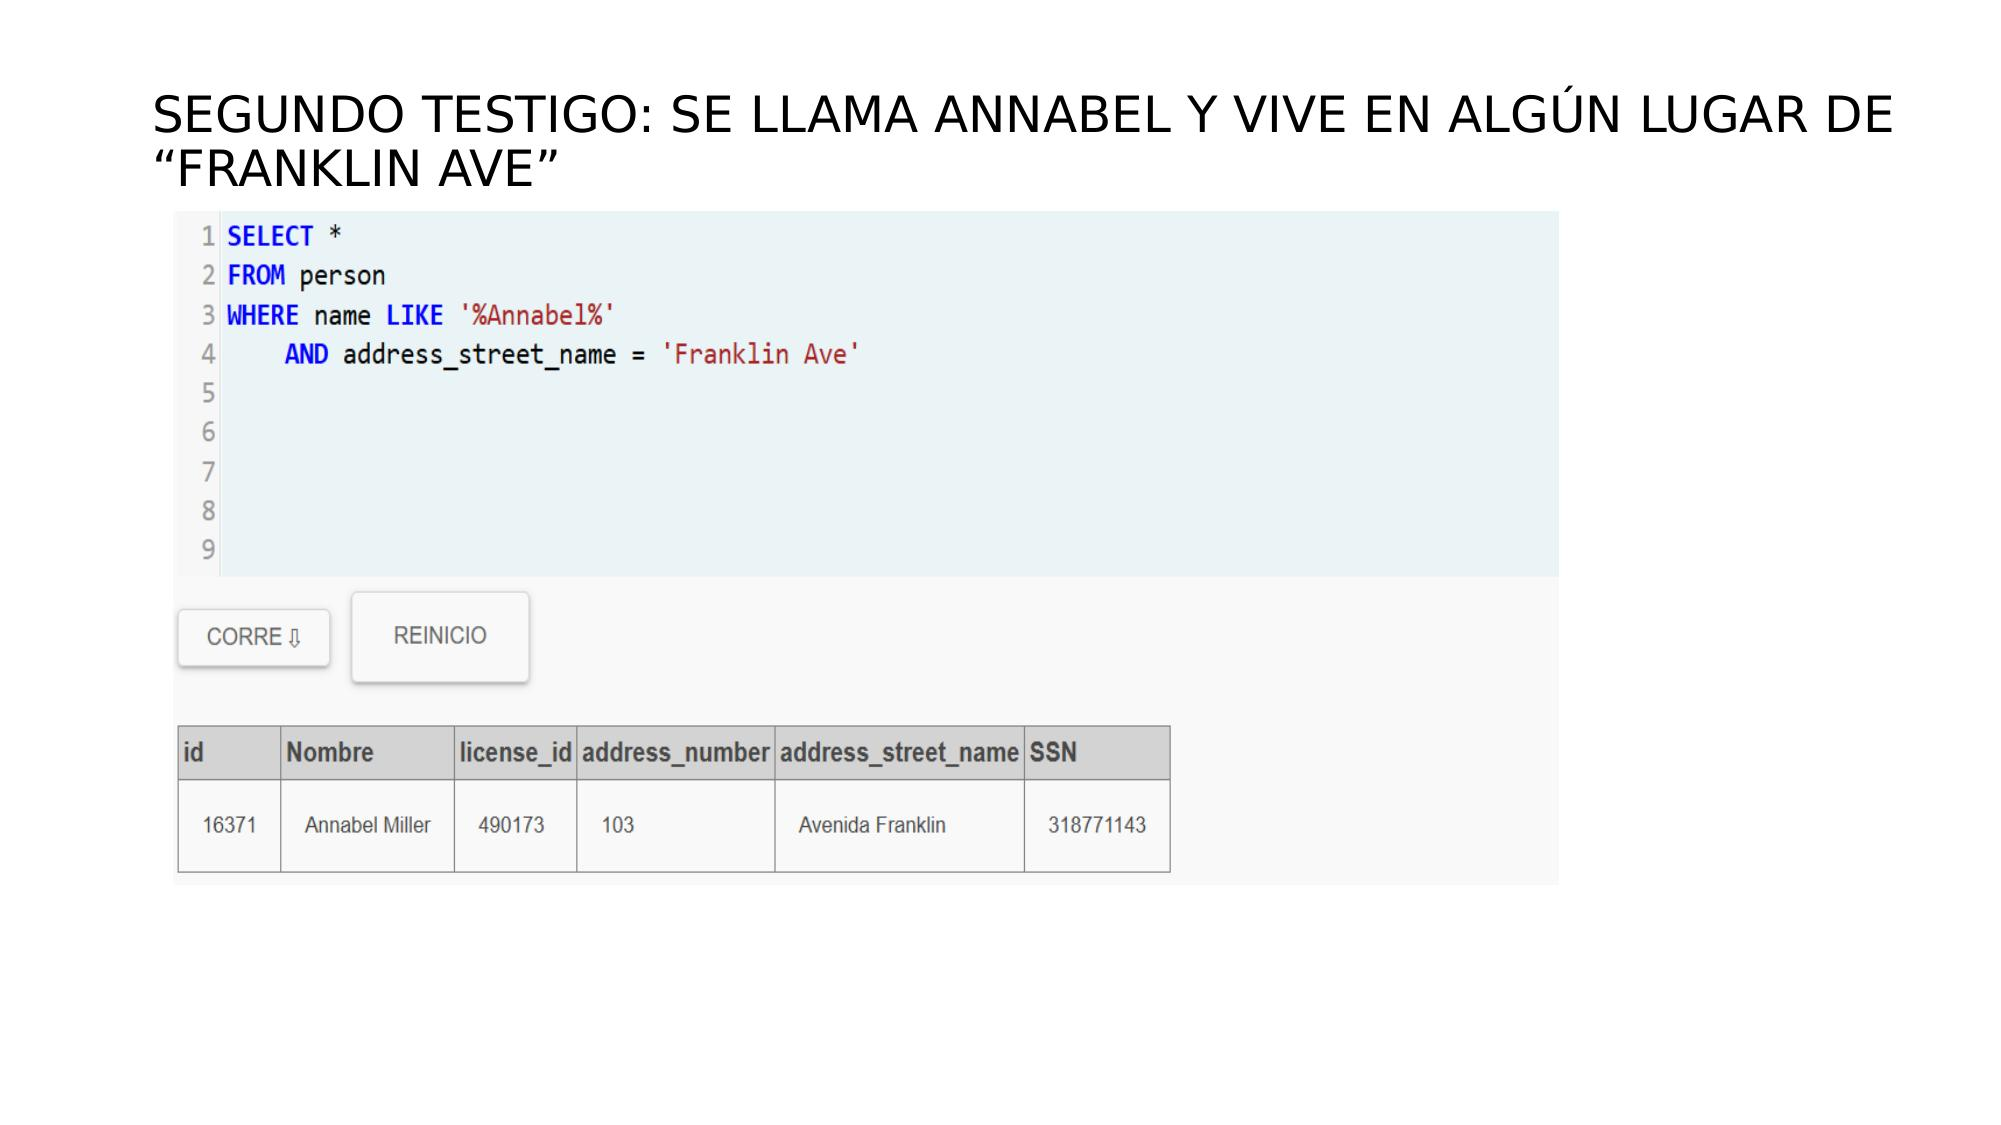

**Resultado:** Testigo 2 → **Annabel Miller** (id: 16371)

---
## Paso 3 — Leer los testimonios

### Testimonio de Morty Schapiro (id: 14887)

In [ ]:
query = """
SELECT *
FROM   interview
WHERE  person_id = 14887
"""
pd.read_sql_query(query, conn)

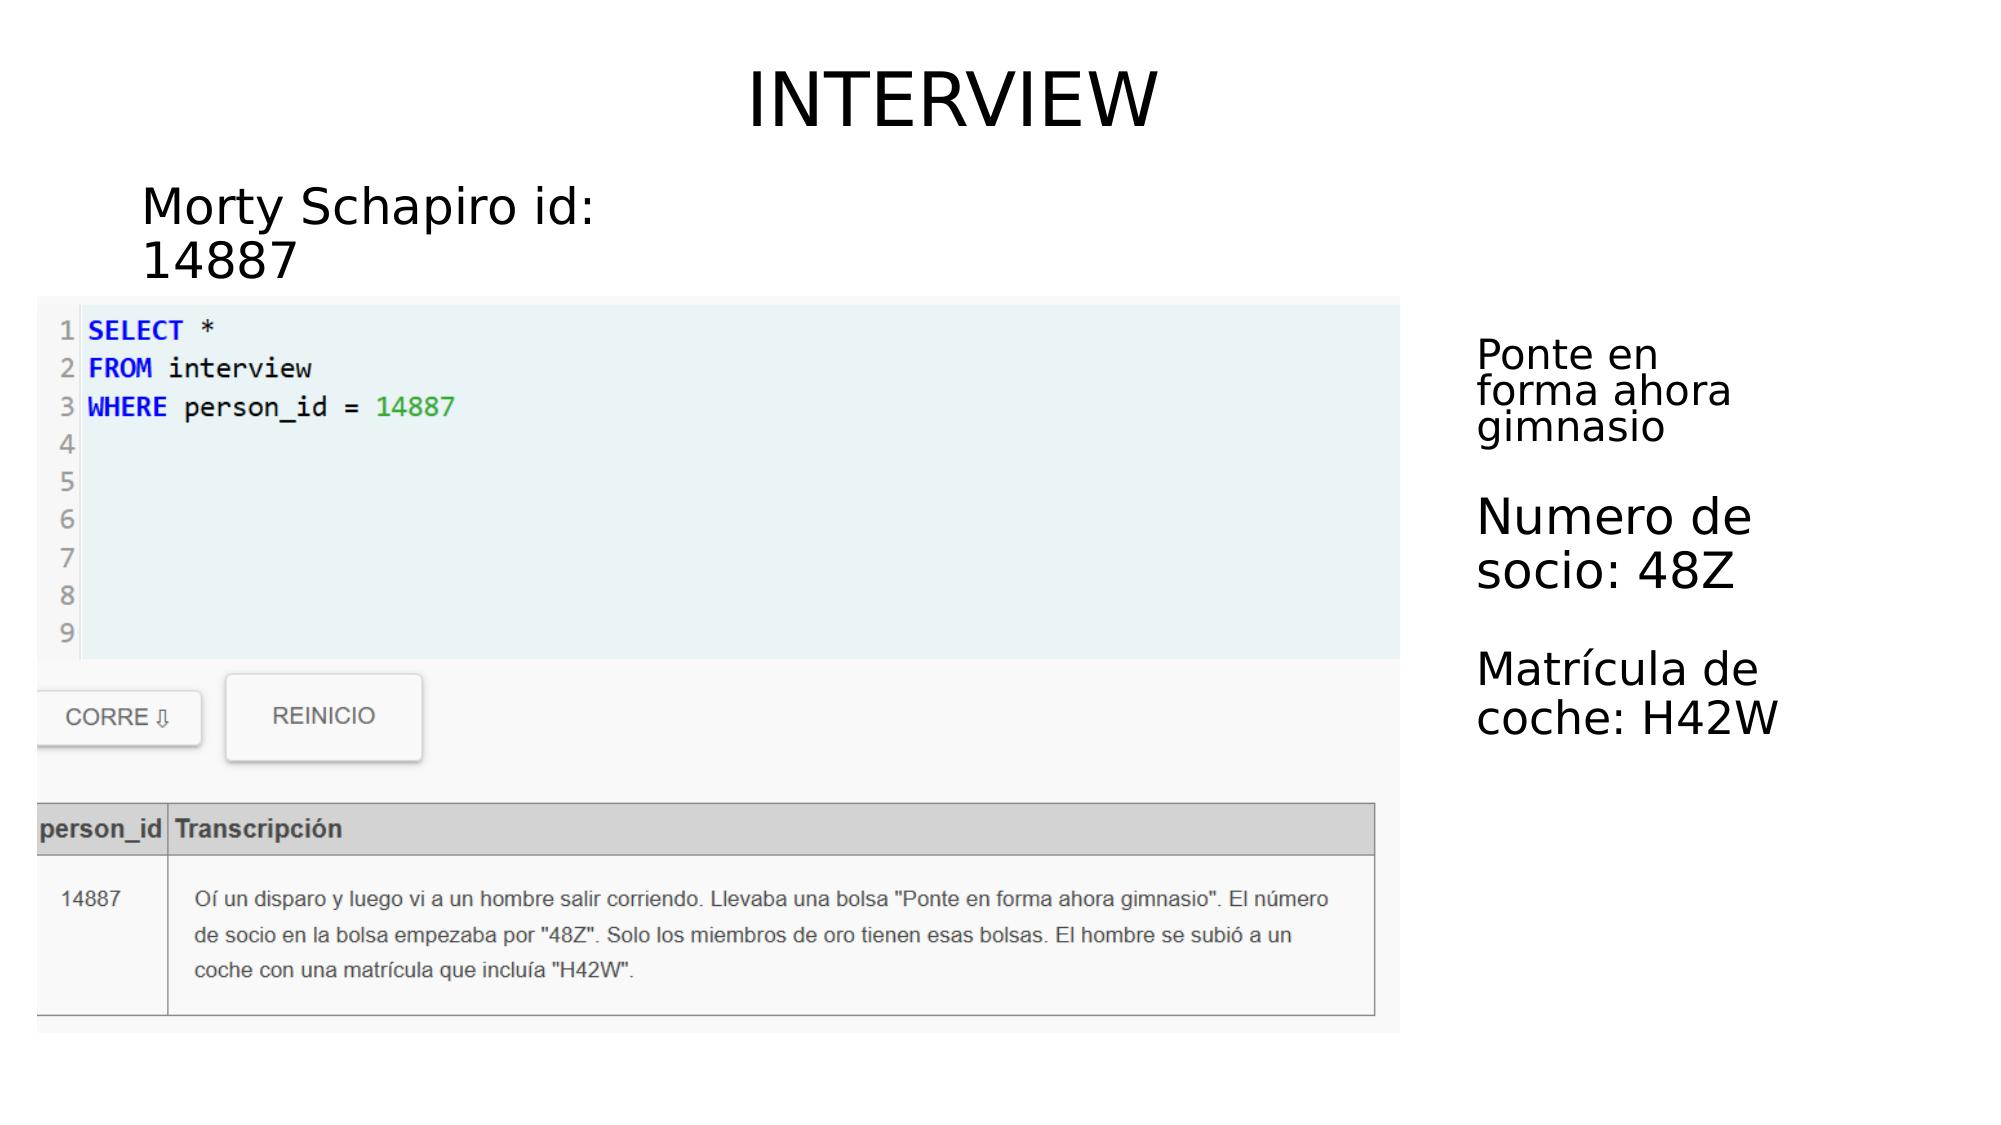

### Testimonio de Annabel Miller (id: 16371)

In [ ]:
query = """
SELECT *
FROM   interview
WHERE  person_id = 16371
"""
pd.read_sql_query(query, conn)

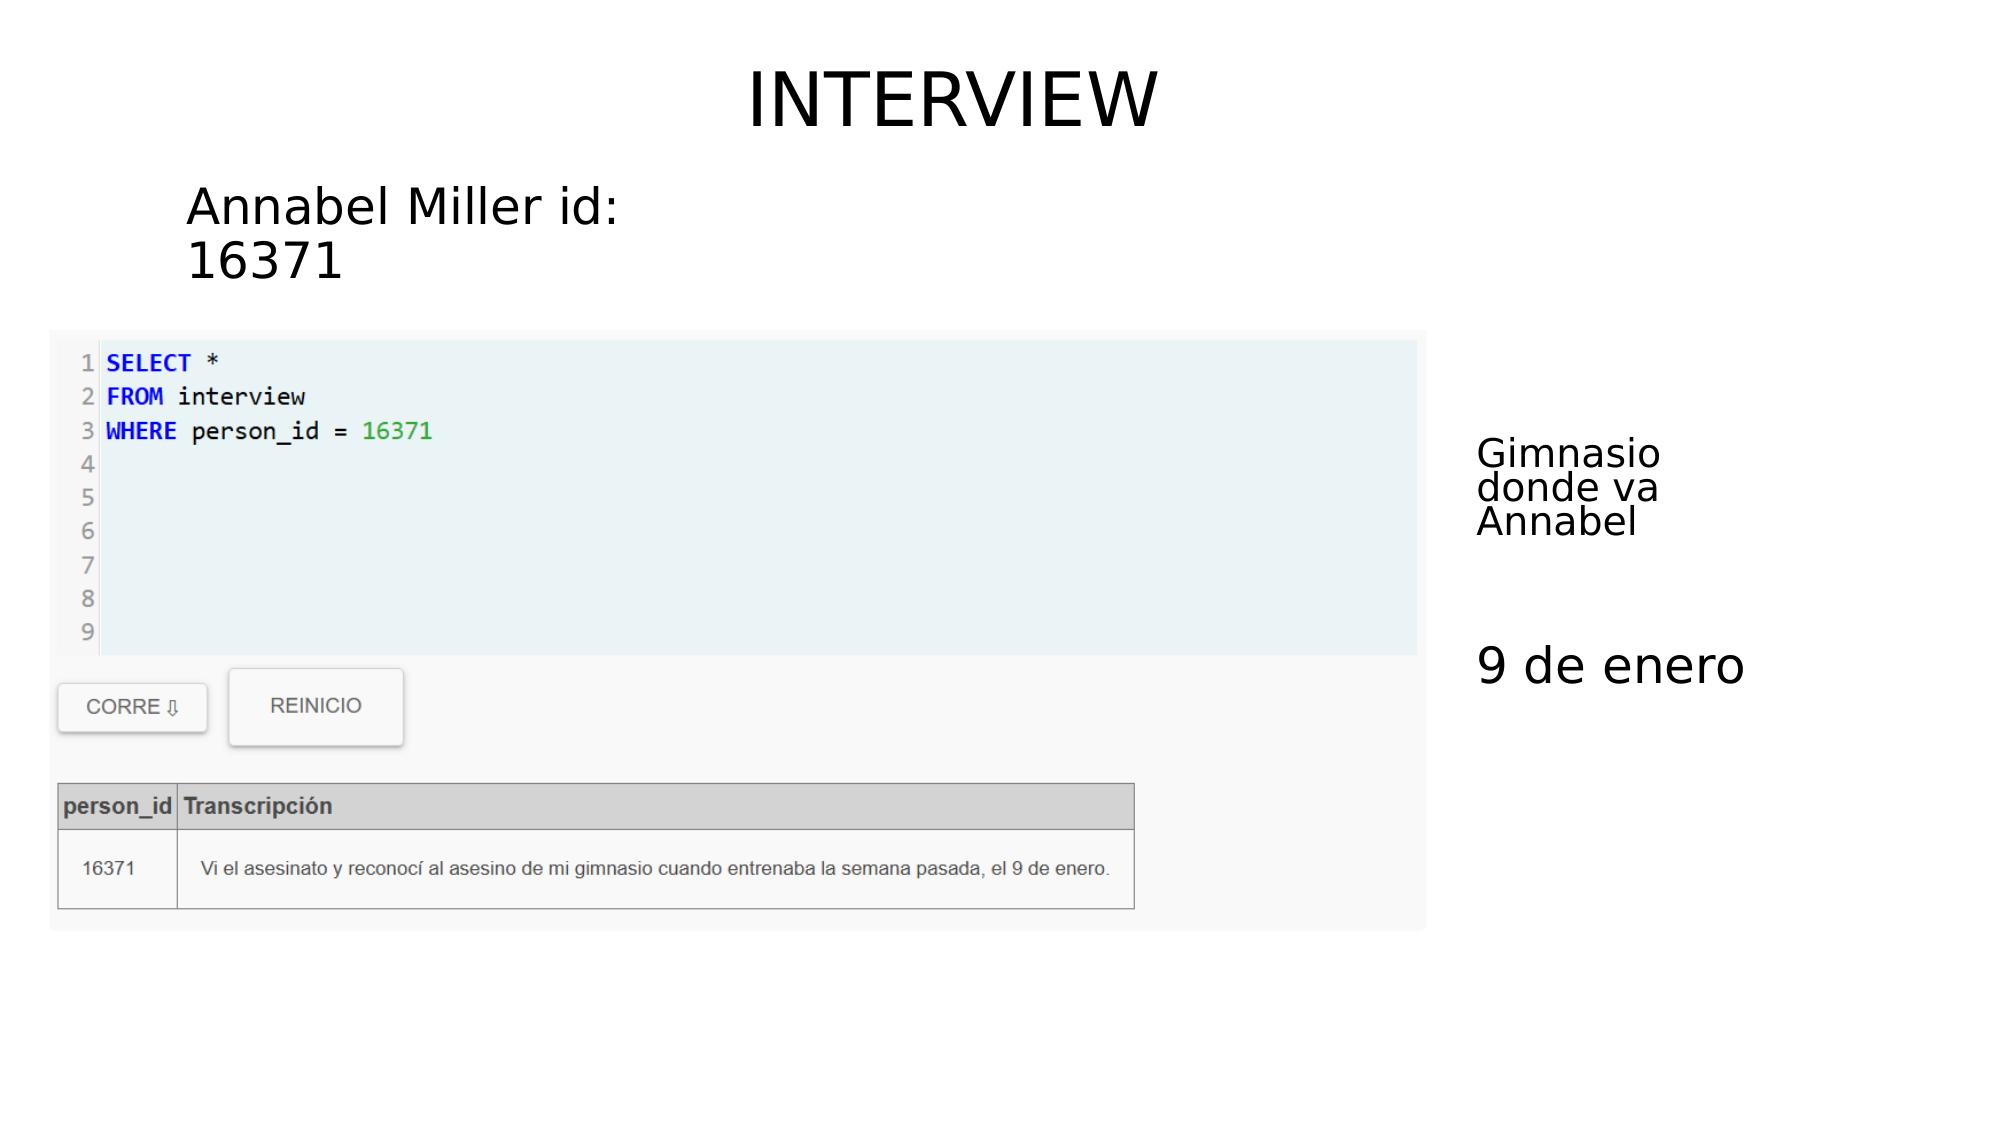

**Pistas obtenidas de los testimonios:**
- Gimnasio: **"Ponte en forma ahora"**
- Número de socio empieza por: **48Z**, tipo **gold**
- Check-in en el gym: **9 de enero de 2018**
- Matrícula del coche contiene: **H42W**

---
## Paso 4 — Rastrear las pistas físicas

Cruzamos las pistas del gimnasio y del vehículo para identificar al sospechoso.

In [ ]:
# Candidatos por membresía del gym (48Z)
query = """
SELECT A.name, B.id
FROM   person AS A
LEFT JOIN get_fit_now_member AS B ON A.id = B.person_id
WHERE  B.id LIKE '48Z%'
"""
pd.read_sql_query(query, conn)

In [ ]:
# Candidatos por matrícula (H42W)
query = """
SELECT A.name, B.plate_number
FROM   person AS A
LEFT JOIN drivers_license AS B ON A.license_id = B.id
WHERE  B.plate_number LIKE '%H42W%'
"""
pd.read_sql_query(query, conn)

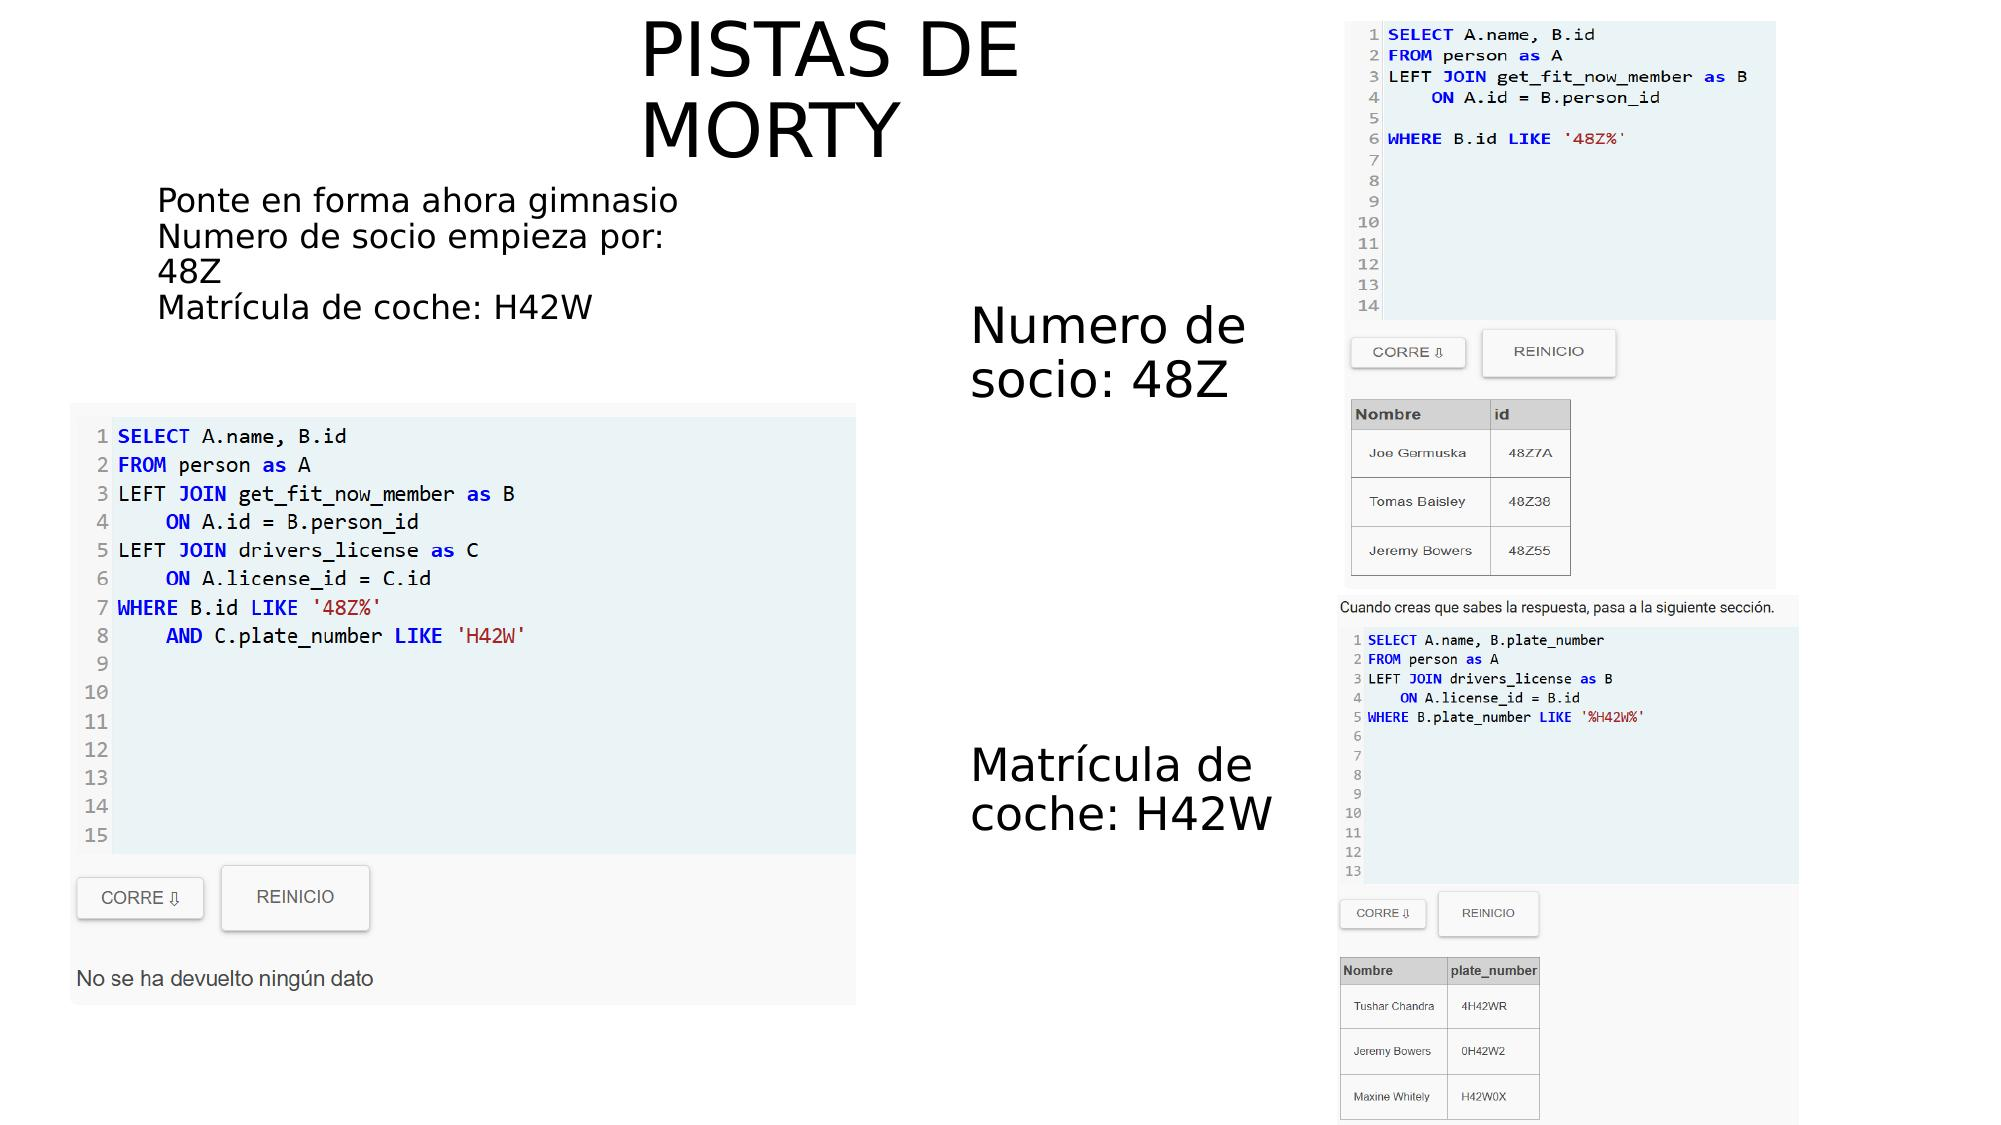

**Conclusión:** El único nombre que aparece en **ambas** listas es **Jeremy Bowers** ✅

---
## Paso 5 — Confirmar al asesino

In [ ]:
conn.execute("INSERT INTO solution (user, value) VALUES (1, 'Jeremy Bowers')")
conn.commit()
pd.read_sql_query("SELECT value FROM solution", conn)

> ✅ **Jeremy Bowers** confirmado como el asesino — pero la investigación no termina aquí: alguien le contrató.

---
## Paso 6 — Investigación adicional: el cerebro del crimen

### 6a — Localizar a Jeremy Bowers en la tabla person

In [ ]:
query = """
SELECT *
FROM   person
WHERE  name LIKE '%Jeremy%'
"""
pd.read_sql_query(query, conn)

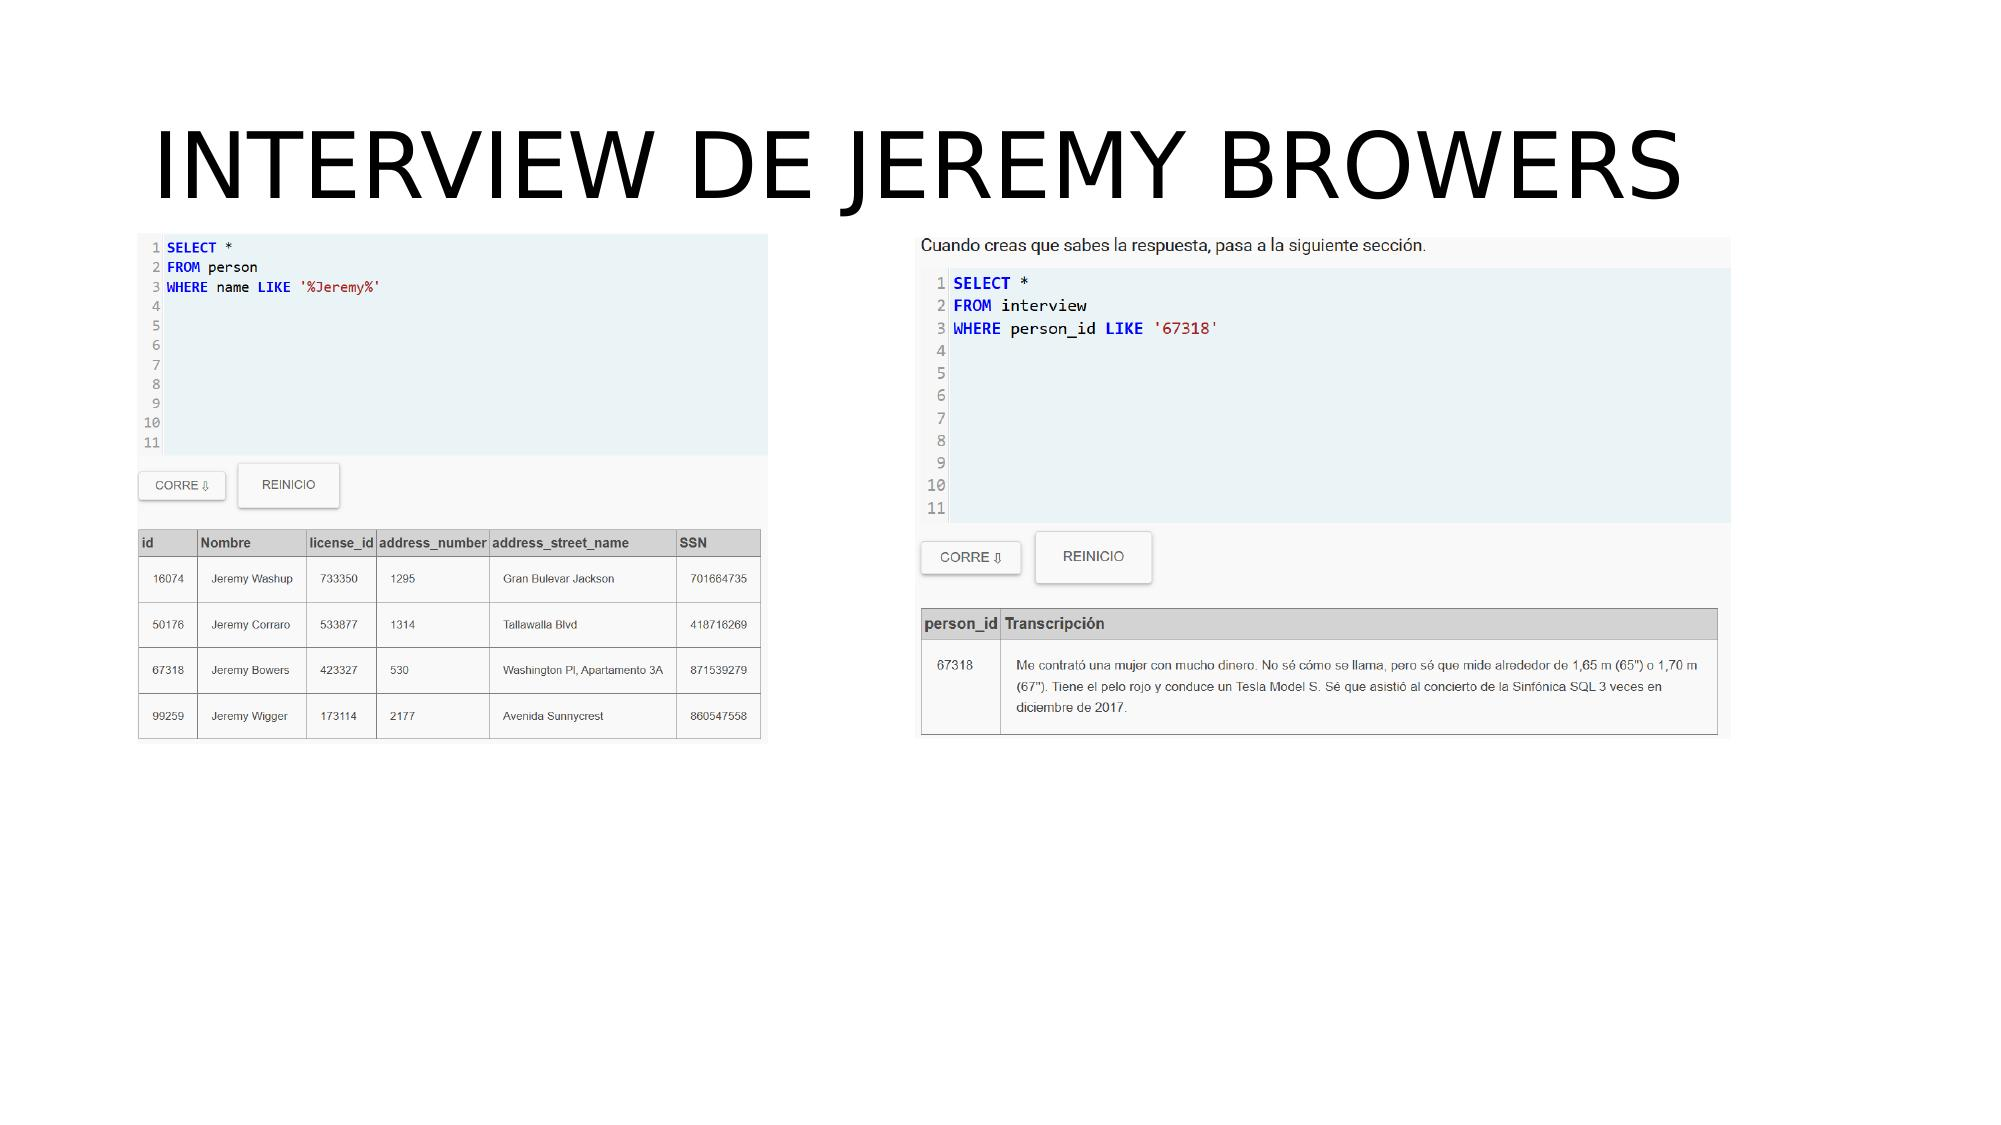

**Resultado:** Jeremy Bowers tiene `id = 67318`

### 6b — Testimonio de Jeremy Bowers (id: 67318)

In [ ]:
query = """
SELECT *
FROM   interview
WHERE  person_id = 67318
"""
pd.read_sql_query(query, conn)

**Nuevas pistas:**
- Género: **mujer**
- Altura: entre **65 y 67 pulgadas**
- Color de pelo: **rojo**
- Coche: **Tesla Model S**
- Evento: **SQL Symphony Concert**, asistió **3 veces** en diciembre de 2017

### 6c — Identificar al cerebro por características físicas

In [ ]:
query = """
SELECT B.name, B.id, A.id AS license_id
FROM   drivers_license AS A
JOIN   person AS B ON B.license_id = A.id
WHERE  A.gender     = 'female'
  AND  A.hair_color = 'red'
  AND  A.height     BETWEEN 65 AND 67
  AND  A.car_make   = 'Tesla'
  AND  A.car_model  = 'Model S'
"""
pd.read_sql_query(query, conn)

### 6d — Confirmar con asistencia al SQL Symphony Concert (3 veces en dic 2017)

In [ ]:
query = """
SELECT B.id, B.name
FROM   facebook_event_checkin AS A
JOIN   person AS B ON A.person_id = B.id
WHERE  A.event_name LIKE '%SQL%'
  AND  A.date BETWEEN 20171201 AND 20171231
  AND  A.person_id IN (
         SELECT person_id
         FROM   facebook_event_checkin
         WHERE  event_name LIKE '%SQL%'
           AND  date BETWEEN 20171201 AND 20171231
         GROUP BY person_id
         HAVING COUNT(*) = 3
       )
"""
pd.read_sql_query(query, conn)

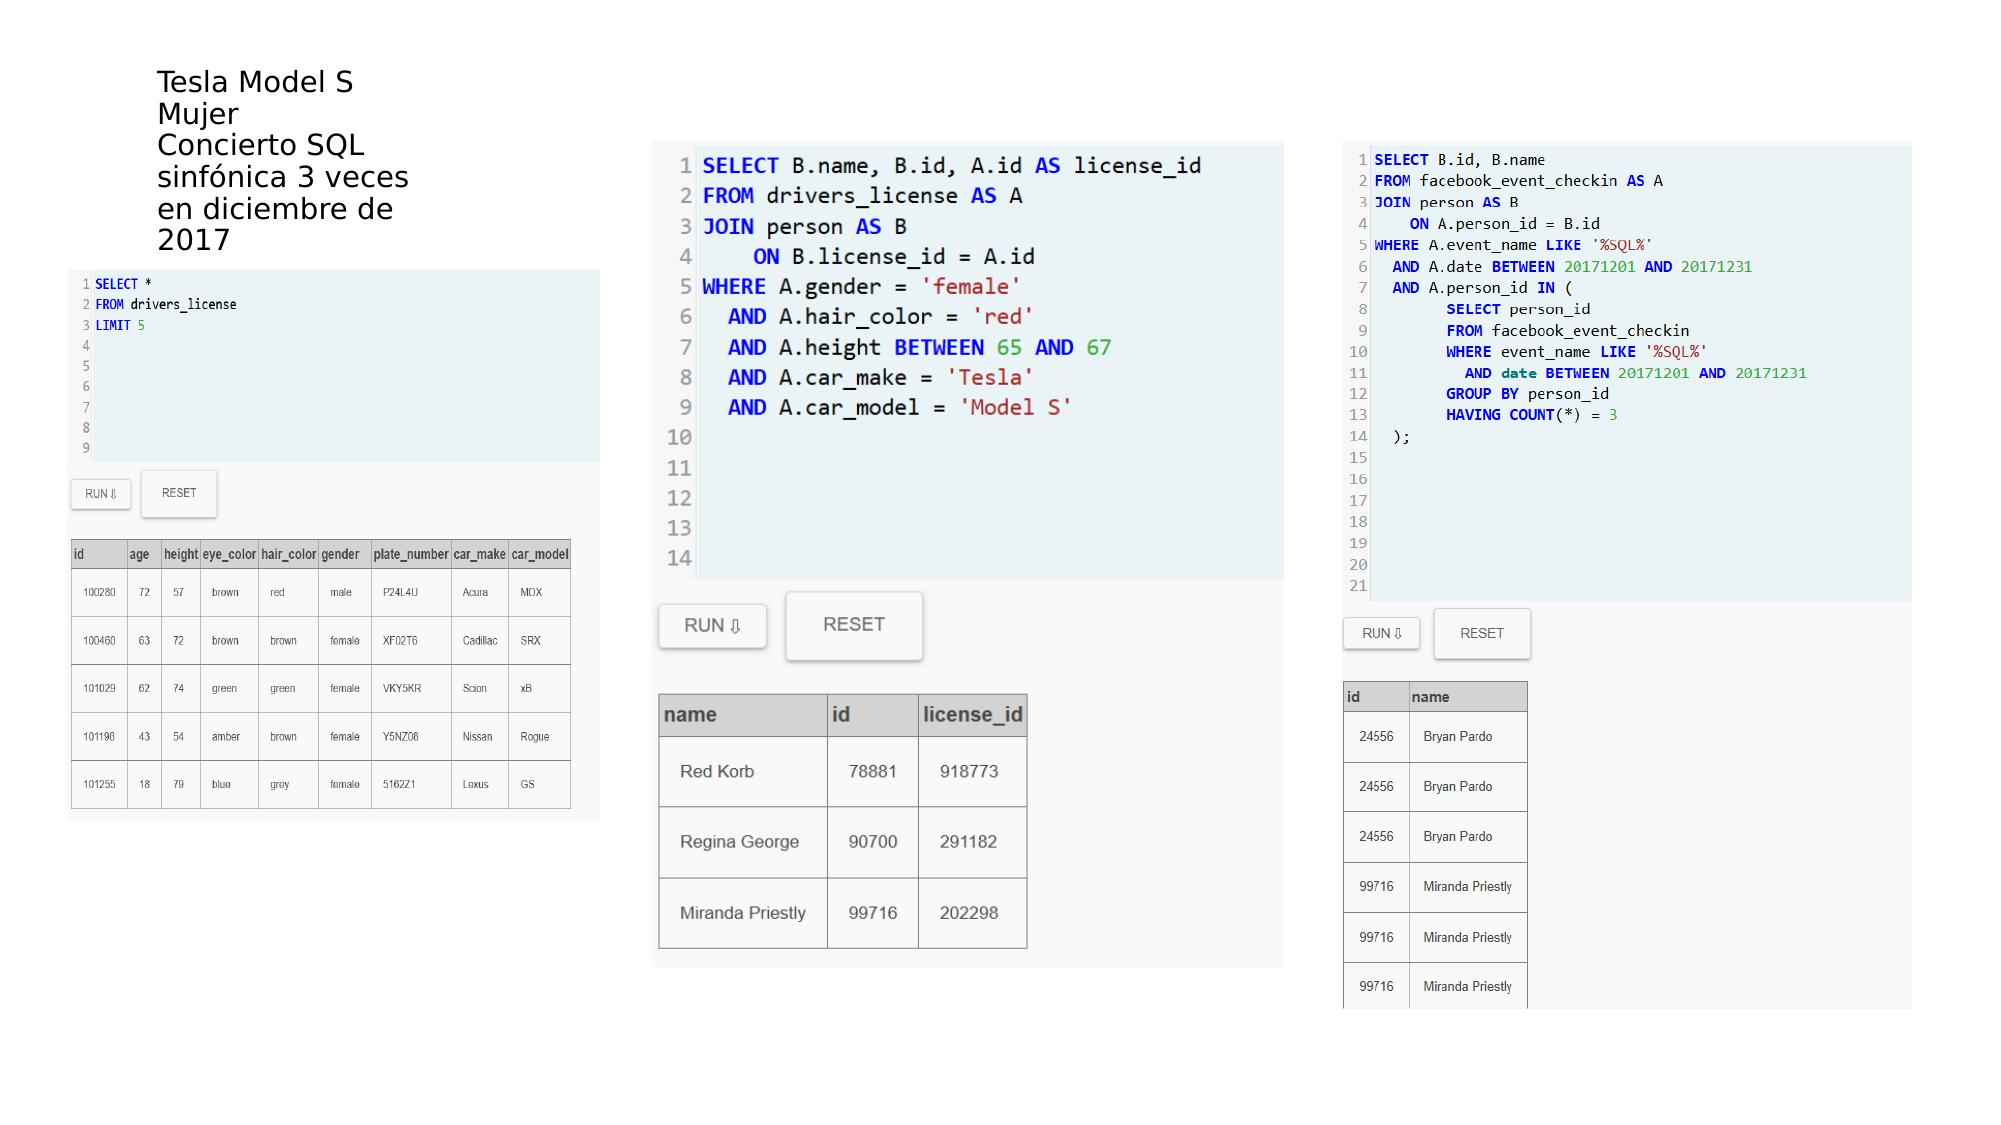

**Cerebro del crimen identificado:** `Miranda Priestly` ✅

---
## Paso 7 — Confirmar la solución final

In [ ]:
conn.execute("INSERT INTO solution (user, value) VALUES (1, 'Miranda Priestly')")
conn.commit()
pd.read_sql_query("SELECT value FROM solution", conn)

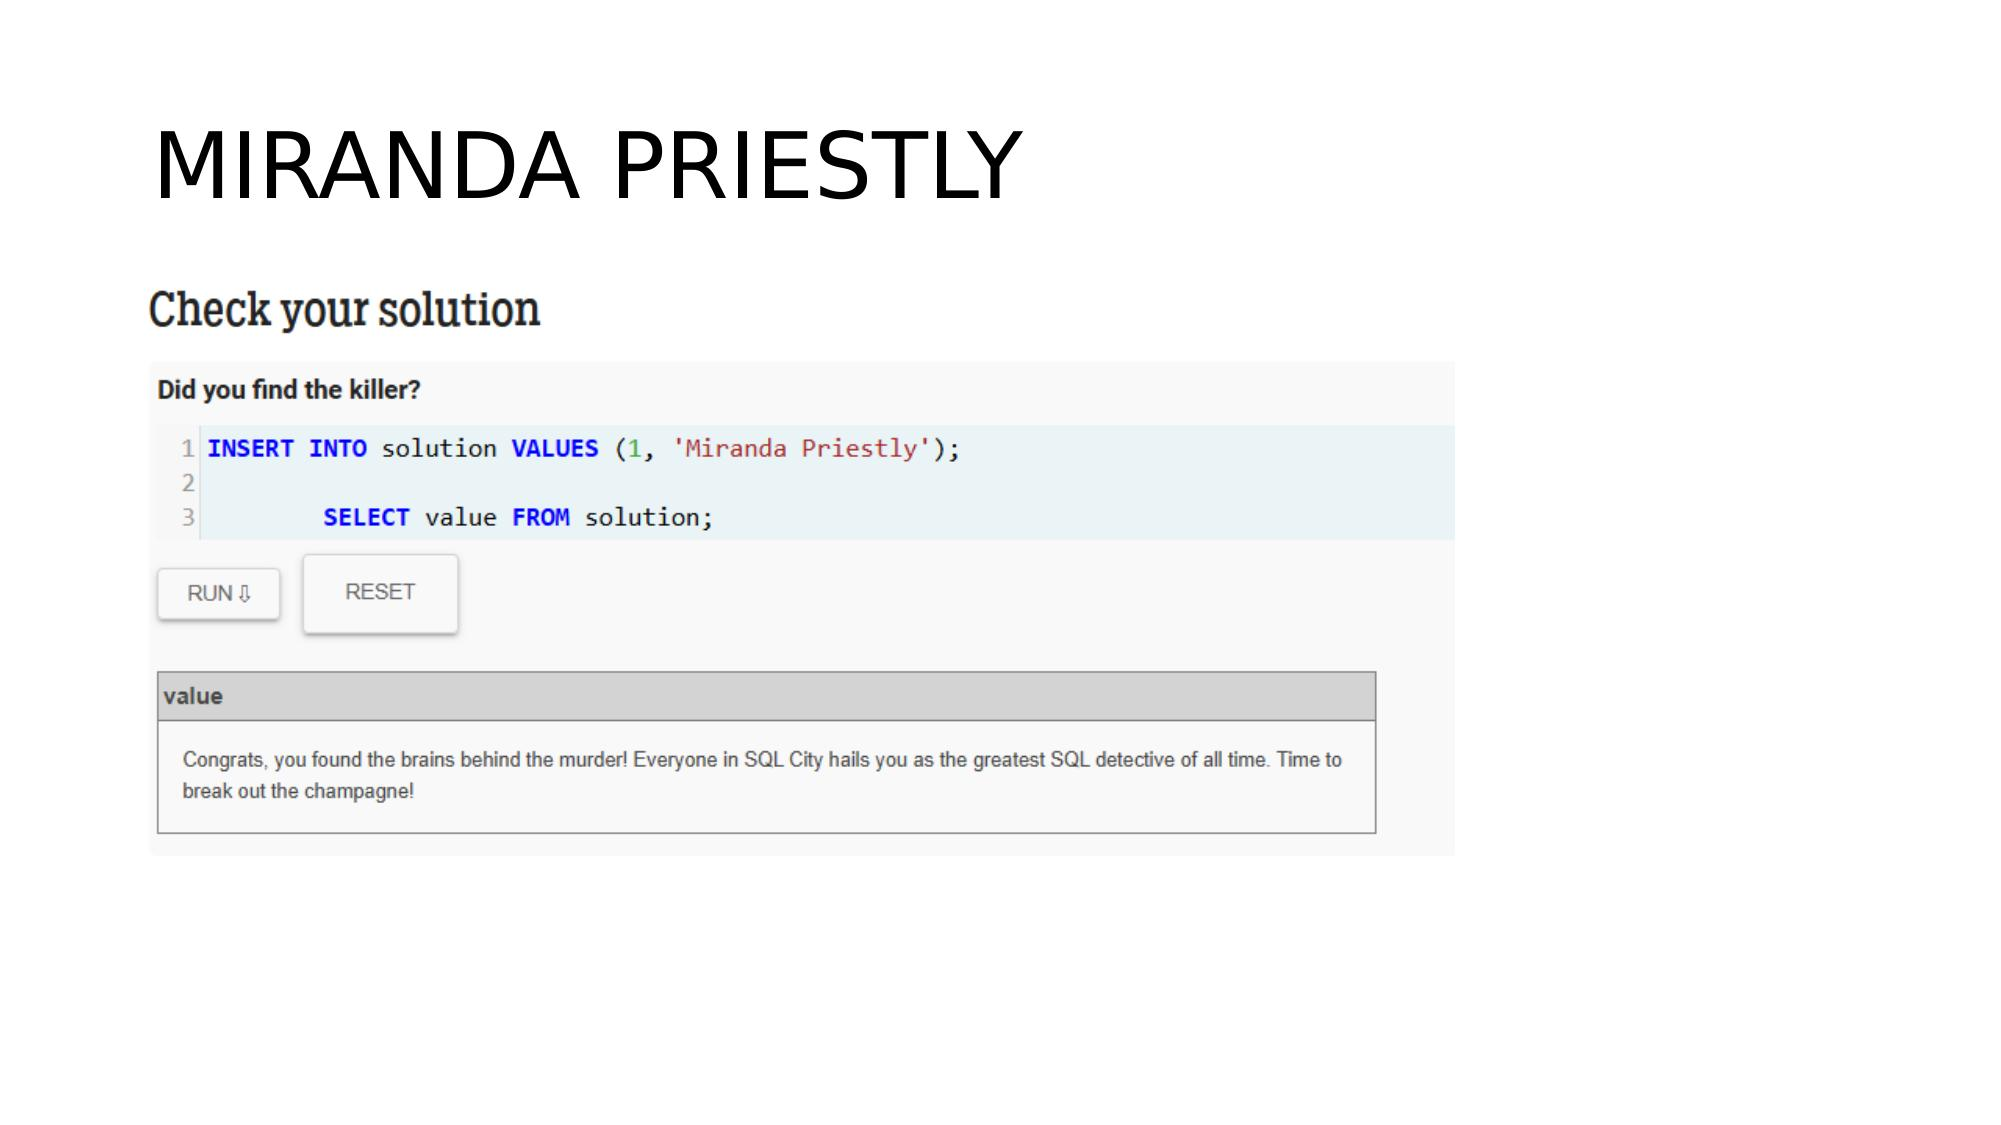

> 🎉 **"Congrats, you found the brains behind the murder! Everyone in SQL City hails you as the greatest SQL detective of all time. Time to break out the champagne!"**

---
## ✅ Conclusión

| Rol | Nombre |
|-----|--------|
| 🔪 **Asesino (sicario)** | Jeremy Bowers |
| 🧠 **Cerebro del crimen** | Miranda Priestly |

> *Caso cerrado. SQL City puede dormir tranquila.*

---

*Resuelto por el Grupo 4 · Bootcamp Data Science*